# Examen 06/06/26

In [30]:
# Importamos librerías

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
from scipy.stats import norm, kurtosis
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from scipy.stats import chi2
from rapidfuzz.distance import Jaro, JaroWinkler, Levenshtein

## Ejercicio 1

In [ ]:
# Cargamos el data set

data = pd.read_csv('../../datasets/pacientes_clinica.csv')
data.head()

,id_paciente,edad,imc,glucosa,actividad_fisica,tabaquismo,presion_sistolica
0,CL-0824,55,29.3,106.0,0,1,150.7
1,RM-0657,51,27.3,84.9,1,1,147.8
2,HC-0097,73,26.9,75.3,1,0,138.4
3,HC-3063,72,27.0,97.6,0,0,141.9
4,PA-5689,32,19.8,95.4,1,0,124.1


In [32]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_paciente        184 non-null    str    
 1   edad               184 non-null    int64  
 2   imc                184 non-null    float64
 3   glucosa            184 non-null    float64
 4   actividad_fisica   184 non-null    int64  
 5   tabaquismo         184 non-null    int64  
 6   presion_sistolica  184 non-null    float64
dtypes: float64(3), int64(3), str(1)
memory usage: 10.2 KB


In [48]:
data['id_paciente'].value_counts()

id_paciente
CL-0824    1
RM-0657    1
HC-0097    1
HC-3063    1
PA-5689    1
          ..
HC-6890    1
PA-6918    1
HC-8286    1
HC-0108    1
RM-9445    1
Name: count, Length: 184, dtype: int64

Observamos que las variables son las enunciadas en el TP y las variables son numéricas salvo por la variable 'id_paciente'. Vamos a chequear que las variables dummies asumen los valores 0 y 1.

In [34]:
data['actividad_fisica'].unique()

array([0, 1])

In [35]:
data['tabaquismo'].unique()

array([1, 0])

## Ejercicio 2

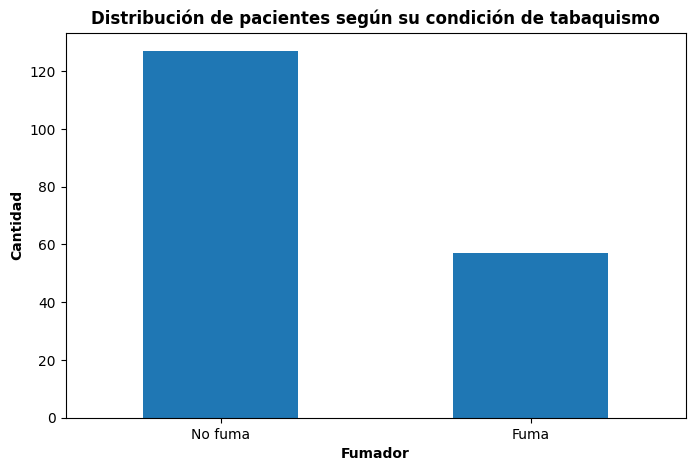

In [63]:
# Vamos a utilizar un gráfico de bastones

plt.figure(figsize = (8,5))
data['tabaquismo'].map({0:'No fuma',1:'Fuma'}).value_counts().plot.bar()
plt.title("Distribución de pacientes según su condición de tabaquismo" , fontweight = 'bold')
plt.xlabel('Fumador', fontweight = 'bold')
plt.xticks(rotation=0)
plt.ylabel('Cantidad', fontweight = 'bold')
plt.show()

In [37]:
# Cantidad de pacientes fumadores

print("Porcentaje de fumadortes:", round(data["tabaquismo"].sum() / 184, 2)*100, '%')

Porcentaje de fumadortes: 31.0 %


## Ejercicio 3

Vamos a considerar la medida de JaroWinkler ya que esta le da peso al prefijo común.


In [38]:
# Generamos una copia de dataset para agregar nuevas columnas para
# almacenar los datos obtenidos

data2 = data.copy()

p = []

for paciente in data['id_paciente']:
    p.append(round(JaroWinkler.similarity('CL-0A81', paciente), 2))

data2['CL-OA81'] = p

data2[data2['CL-OA81']>0.9]

# Para el candidato 'CL-0A81' obtenemos solo el paciente 'CL-0481'.

,id_paciente,edad,imc,glucosa,actividad_fisica,tabaquismo,presion_sistolica,CL-OA81
91,CL-0481,48,24.3,88.0,1,0,129.4,0.94


In [39]:
p = []

for paciente in data['id_paciente']:
    p.append(round(JaroWinkler.similarity('CI-1B27', paciente), 2))

data2['CI-1B27'] = p

data2[data2['CI-1B27']>0.9]

# Para el candidato 'CI-1B27' no obtenemos pacientes.

,id_paciente,edad,imc,glucosa,actividad_fisica,tabaquismo,presion_sistolica,CL-OA81,CI-1B27


# Ejercicio 4

Consideremos el modelo:

$$Y = \beta_1 + \beta_2 X_{edad} + \beta_3 X_{imc} + \beta_4 X_{glucosa} + \beta_5 X_{fisica} + \beta_6 X_{tabaquismo} + \beta_7 X_{presion}$$

Observemos que no consideramos la variable "id_paciente" ya que es una variable que asume un valor único por paciente (no quería eliminarla por el Ejercicio 2).

In [40]:
# Calculamos las variables y los p-value

pd.get_dummies(data['actividad_fisica'], drop_first = True)
pd.get_dummies(data['tabaquismo'], drop_first = True)

modelo = smf.ols(
    formula = 'presion_sistolica ~ edad + imc + glucosa + C(actividad_fisica) + C(tabaquismo)',
    data = data).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:      presion_sistolica   R-squared:                       0.754
Model:                            OLS   Adj. R-squared:                  0.747
Method:                 Least Squares   F-statistic:                     109.0
Date:                Fri, 26 Jun 2026   Prob (F-statistic):           2.85e-52
Time:                        15:49:03   Log-Likelihood:                -598.64
No. Observations:                 184   AIC:                             1209.
Df Residuals:                     178   BIC:                             1229.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

Con un nivel de significancia del 5% (0.05) consideramos que la variable 'actividad_fisica' no es significativa. La eliminamos del modelo.

In [41]:
modelo2 = smf.ols(
    formula = 'presion_sistolica ~ edad + imc + glucosa + C(tabaquismo)',
    data = data).fit()

print(modelo2.summary())

                            OLS Regression Results                            
Dep. Variable:      presion_sistolica   R-squared:                       0.753
Model:                            OLS   Adj. R-squared:                  0.748
Method:                 Least Squares   F-statistic:                     136.8
Date:                Fri, 26 Jun 2026   Prob (F-statistic):           2.57e-53
Time:                        15:49:03   Log-Likelihood:                -598.77
No. Observations:                 184   AIC:                             1208.
Df Residuals:                     179   BIC:                             1224.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             49.8068      4

El modelo ajustado obtenido es

$$Y = 49.8068 + 0.5191 X_{edad} + 1.3770 X_{imc} + 0.2124 X_{glucosa} + 7.0325 X_{tabaquismo}$$

In [42]:
# Cargamos los datos del paciente

X_edad = 50
X_imc = 28.5
X_glucosa = 102
X_tabaquismo = 0

# Predicción

print("Presión:", round(49.8068 + 0.5191 *X_edad + 1.3770 *X_imc + 0.2124 *X_glucosa + 7.0325 *X_tabaquismo,2))

Presión: 136.67


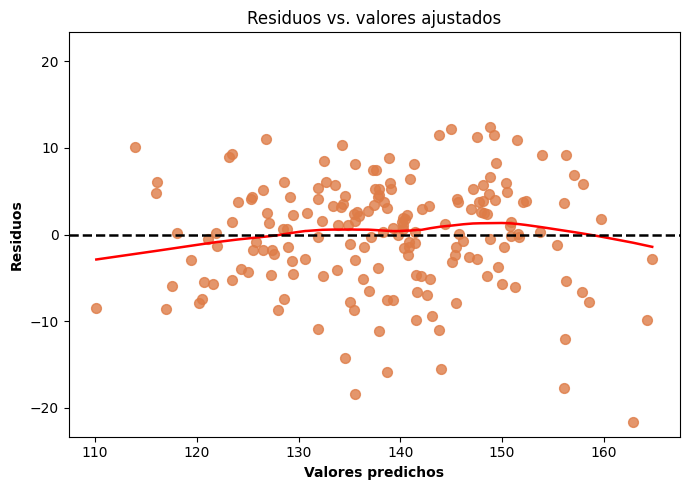

In [43]:
# Consideremos el gráfico

fig, ax = plt.subplots(figsize=(7, 5))

sns.regplot(x = modelo2.fittedvalues, y = modelo2.resid,
            lowess = True,
            line_kws = dict(color = 'red', linewidth = 1.8),
            scatter_kws = dict(s = 50, edgecolor = '#de7c47', color = '#de7c47'),
            ax = ax)

ax.axhline(y = 0, color = 'black', linestyle = '--', linewidth = 1.8)
ax.set_xlabel('Valores predichos', fontweight = 'bold')
ax.set_ylabel('Residuos', fontweight = 'bold')
ax.set_title('Residuos vs. valores ajustados')

low, high = ax.get_ylim()
bound = max(abs(low), abs(high))
ax.set_ylim(-bound, bound)

plt.tight_layout()
plt.show()